# 🖼️ Image Captioning with CNN–RNN on MS COCO
**German International University of Applied Sciences**  
Advanced Machine Learning — Spring 2026 | Assignment 2

**Team members:** *(fill in your names and IDs here)*

---
### Project Overview
This notebook implements an end-to-end image captioning pipeline:
1. **CNN Encoder** — EfficientNetB0 (pretrained on ImageNet) extracts a 1280-dim visual feature vector from each image.
2. **Auxiliary classifier** — a small dense head predicts MS COCO top-level object categories as extra supervision to sharpen features.
3. **RNN Decoder** — an LSTM generates captions word-by-word conditioned on the image embedding.
4. **Evaluation** — BLEU-1 through BLEU-4 scores on the held-out test split.

Works on **Google Colab (T4)** and **local GPU (RTX 4060)**.

## 0 · Environment Setup

In [ ]:
# Install / upgrade required libraries
# Run this cell first — it is safe to re-run
import subprocess, sys

packages = [
    'kaggle',          # dataset download
    'pycocotools',     # MS COCO annotation API
    'nltk',            # BLEU score computation
    'tqdm',            # progress bars
    'Pillow',          # image loading
    'matplotlib',      # visualisation
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('✅ All packages installed.')

✅ All packages installed.


In [ ]:
# ── Standard library ──────────────────────────────────────────────
import os, json, random, string, time, pickle
from pathlib import Path
from collections import Counter

# ── Numeric / IO ───────────────────────────────────────────────────
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── Deep learning ─────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ── NLP ────────────────────────────────────────────────────────────
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── COCO API ────────────────────────────────────────────────────────
from pycocotools.coco import COCO

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPUs available     : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1 · Dataset Download & Paths

> **One-time setup:** Upload your `kaggle.json` API key (Kaggle → Account → Create New Token) and run the next cell.  
> Skip if you already have the data downloaded.

In [ ]:
# ── Kaggle credentials setup ───────────────────────────────────────
import os, json
from pathlib import Path

KAGGLE_USERNAME = "lakshyrupani"          # ← change this
KAGGLE_KEY      = "9e17938f6f8e83a3b19420acdb64ad73"  # ← your token

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(kaggle_dir / 'kaggle.json', 'w') as f:
    json.dump(creds, f)

os.chmod(kaggle_dir / 'kaggle.json', 0o600)
print('✅ Kaggle credentials saved.')

✅ Kaggle credentials saved.


In [ ]:
# ── Download MS COCO dataset from Kaggle ───────────────────────────

DATA_ROOT = Path('coco_data')
DATA_ROOT.mkdir(exist_ok=True)

zip_path = DATA_ROOT / 'ms-coco-dataset.zip'

# Delete corrupted zip if it exists
if zip_path.exists():
    zip_path.unlink()
    print('🗑️ Deleted old corrupted zip.')

# Download fresh
os.system(f'kaggle datasets download -d hariwh0/ms-coco-dataset -p {DATA_ROOT} --force')
print('✅ Download complete.')

# Verify it's a valid zip before extracting
import zipfile
if zipfile.is_zipfile(zip_path):
    print('✅ ZIP is valid, extracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_ROOT)
    print('✅ Extraction complete.')
else:
    print('❌ ZIP is still corrupted. Check your internet connection and re-run.')

✅ Download complete.
✅ ZIP is valid, extracting...
✅ Extraction complete.


In [ ]:
# ── Path configuration ─────────────────────────────────────────────

DATA_ROOT      = Path('coco_data')   # adjust if your data is elsewhere

TRAIN_IMG_DIR  = DATA_ROOT / 'train2014' / 'train2014'
VAL_IMG_DIR    = DATA_ROOT / 'train2014' / 'train2014'  # no separate val folder in this dataset
ANNOT_DIR      = DATA_ROOT / 'captions' / 'annotations'

TRAIN_CAPTIONS = ANNOT_DIR / 'captions_train2014.json'
VAL_CAPTIONS   = ANNOT_DIR / 'captions_val2014.json'
TRAIN_INSTANCES= ANNOT_DIR / 'instances_train2014.json'

# Verify paths exist
for p in [TRAIN_IMG_DIR, ANNOT_DIR, TRAIN_CAPTIONS, VAL_CAPTIONS]:
    status = '✅' if p.exists() else '❌ MISSING'
    print(f'{status}  {p}')

✅  coco_data/train2014/train2014
✅  coco_data/captions/annotations
✅  coco_data/captions/annotations/captions_train2014.json
✅  coco_data/captions/annotations/captions_val2014.json


## 2 · Data Preprocessing

### 2-a · Caption Cleaning & Tokenization

In [ ]:
# ── Load COCO caption annotations ─────────────────────────────────

def load_coco_captions(json_path):
    """Returns {image_id: [caption1, caption2, ...]} dict."""
    with open(json_path) as f:
        data = json.load(f)
    captions_dict = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        captions_dict.setdefault(img_id, []).append(ann['caption'])
    # Also build image_id → file_name mapping
    id_to_file = {img['id']: img['file_name'] for img in data['images']}
    return captions_dict, id_to_file

train_captions, train_id2file = load_coco_captions(TRAIN_CAPTIONS)
val_captions,   val_id2file   = load_coco_captions(VAL_CAPTIONS)

print(f'Training images with captions : {len(train_captions):,}')
print(f'Validation images with captions: {len(val_captions):,}')

Training images with captions : 82,783
Validation images with captions: 40,504


In [ ]:
# ── Caption cleaning ───────────────────────────────────────────────
# Steps: lowercase → remove punctuation → strip whitespace
# Special tokens: <start> marks the beginning, <end> marks the end of each caption.

def clean_caption(caption: str) -> str:
    """Lowercase, strip punctuation, collapse whitespace."""
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = ' '.join(caption.split())   # collapse multiple spaces
    return caption

def wrap_caption(caption: str) -> str:
    """Add <start> and <end> sentinel tokens."""
    return f'<start> {clean_caption(caption)} <end>'

# Apply to all splits
def clean_captions_dict(captions_dict):
    return {img_id: [wrap_caption(c) for c in caps]
            for img_id, caps in captions_dict.items()}

train_captions = clean_captions_dict(train_captions)
val_captions   = clean_captions_dict(val_captions)

# Show a cleaned example
sample_id = list(train_captions.keys())[0]
print('Sample cleaned captions for image', sample_id)
for c in train_captions[sample_id]:
    print(' ', c)

Sample cleaned captions for image 318556
  <start> a very clean and well decorated empty bathroom <end>
  <start> a blue and white bathroom with butterfly themed wall tiles <end>
  <start> a bathroom with a border of butterflies and blue paint on the walls above it <end>
  <start> an angled view of a beautifully decorated bathroom <end>
  <start> a clock that blends in with the wall hangs in a bathroom <end>


### 2-b · Vocabulary Construction

In [ ]:
# ── Build vocabulary from training captions ────────────────────────
# Words that appear fewer than MIN_FREQ times are replaced with <unk>.

MIN_FREQ = 5   # frequency threshold — keeps vocab manageable

word_counts = Counter()
for caps in train_captions.values():
    for cap in caps:
        word_counts.update(cap.split())

# Special tokens always in vocab
SPECIAL_TOKENS = ['<pad>', '<unk>', '<start>', '<end>']

vocab = SPECIAL_TOKENS + [
    word for word, count in word_counts.items()
    if count >= MIN_FREQ and word not in SPECIAL_TOKENS
]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx['<pad>']
UNK_IDX    = word2idx['<unk>']
START_IDX  = word2idx['<start>']
END_IDX    = word2idx['<end>']

print(f'Vocabulary size (freq ≥ {MIN_FREQ}): {VOCAB_SIZE:,}')

Vocabulary size (freq ≥ 5): 8,844


### 2-c · Sequence Preparation

In [ ]:
# ── Tokenise captions to integer sequences ─────────────────────────

def caption_to_sequence(caption: str) -> list:
    """Convert a cleaned caption string to a list of integer indices."""
    return [word2idx.get(w, UNK_IDX) for w in caption.split()]

# Compute max caption length (used for padding)
all_train_caps = [cap for caps in train_captions.values() for cap in caps]
MAX_LEN = max(len(c.split()) for c in all_train_caps)
print(f'Longest caption (including <start>/<end>): {MAX_LEN} tokens')

# ── Dataset size control (≥50% per assignment spec) ───────────────
# Using 60% of training images for reasonable Colab training time.
# Increase SUBSET_FRAC to 1.0 if you have more time / better hardware.

SUBSET_FRAC = 0.6

all_train_ids = list(train_captions.keys())
random.shuffle(all_train_ids)
subset_size   = int(len(all_train_ids) * SUBSET_FRAC)
train_ids     = all_train_ids[:subset_size]

# Reserve 10% of those for an internal validation split
split_point   = int(0.9 * len(train_ids))
train_ids_fit = train_ids[:split_point]
val_ids_fit   = train_ids[split_point:]

print(f'Training images (fit)      : {len(train_ids_fit):,}')
print(f'Validation images (fit)    : {len(val_ids_fit):,}')
print(f'Test images (val2017)      : {len(val_captions):,}')

Longest caption (including <start>/<end>): 51 tokens
Training images (fit)      : 44,702
Validation images (fit)    : 4,967
Test images (val2017)      : 40,504


### 2-d · Image Feature Extraction (CNN)

We use **EfficientNetB0** pretrained on ImageNet as a frozen feature extractor.  
The global-average-pooled output is a **1280-dimensional** vector that represents the image content.  
Features are precomputed once and cached to disk — this avoids running the CNN on every training step.

In [ ]:
# ── Build the CNN feature extractor ───────────────────────────────
# EfficientNetB0 is lightweight (~5M params) but powerful.
# We remove the classification head (include_top=False) and
# apply GlobalAveragePooling to get a single vector per image.

IMAGE_SIZE   = (224, 224)   # EfficientNetB0 native input size
FEATURE_DIM  = 1280         # output dimension after pooling

base_cnn = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMAGE_SIZE, 3)
)
base_cnn.trainable = False  # freeze — we use it as a fixed encoder

cnn_extractor = Model(
    inputs  = base_cnn.input,
    outputs = layers.GlobalAveragePooling2D()(base_cnn.output),
    name    = 'cnn_extractor'
)

print(f'CNN extractor output shape: {cnn_extractor.output_shape}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN extractor output shape: (None, 1280)


In [ ]:
# ── Precompute and cache image features ───────────────────────────
# Features are stored in a dict {image_id: np.array(1280,)}
# Cached to disk as a .pkl file so this runs only once.

CACHE_FILE = DATA_ROOT / 'image_features_efficientnet.pkl'
BATCH_SIZE_CNN = 64   # how many images to pass through CNN at once

def load_and_preprocess_image(img_path):
    """Load image, resize to 224×224, apply EfficientNet preprocessing."""
    img = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    arr = np.array(img, dtype=np.float32)
    return preprocess_input(arr)

def extract_features_for_ids(img_ids, id2file, img_dir):
    """Extract CNN features for a list of image IDs."""
    features = {}
    # Process in batches for efficiency
    for i in range(0, len(img_ids), BATCH_SIZE_CNN):
        batch_ids   = img_ids[i: i + BATCH_SIZE_CNN]
        batch_imgs  = []
        valid_ids   = []
        for img_id in batch_ids:
            path = img_dir / id2file[img_id]
            if path.exists():
                batch_imgs.append(load_and_preprocess_image(path))
                valid_ids.append(img_id)
        if batch_imgs:
            batch_tensor = np.stack(batch_imgs)
            batch_feats  = cnn_extractor.predict(batch_tensor, verbose=0)
            for img_id, feat in zip(valid_ids, batch_feats):
                features[img_id] = feat
        if (i // BATCH_SIZE_CNN) % 20 == 0:
            print(f'  Processed {min(i + BATCH_SIZE_CNN, len(img_ids)):,} / {len(img_ids):,}')
    return features

if CACHE_FILE.exists():
    print('✅ Loading cached features from disk...')
    with open(CACHE_FILE, 'rb') as f:
        all_features = pickle.load(f)
    print(f'   Loaded features for {len(all_features):,} images.')
else:
    print('Extracting training features...')
    all_features = extract_features_for_ids(train_ids, train_id2file, TRAIN_IMG_DIR)
    print('Extracting val2017 features (for test evaluation)...')
    val_feats = extract_features_for_ids(
        list(val_captions.keys())[:5000], val_id2file, VAL_IMG_DIR
    )
    all_features.update(val_feats)
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(all_features, f)
    print(f'✅ Cached features for {len(all_features):,} images.')

Extracting training features...
  Processed 64 / 49,669
  Processed 1,344 / 49,669
  Processed 2,624 / 49,669
  Processed 3,904 / 49,669
  Processed 5,184 / 49,669
  Processed 6,464 / 49,669
  Processed 7,744 / 49,669
  Processed 9,024 / 49,669
  Processed 10,304 / 49,669
  Processed 11,584 / 49,669
  Processed 12,864 / 49,669
  Processed 14,144 / 49,669
  Processed 15,424 / 49,669
  Processed 16,704 / 49,669
  Processed 17,984 / 49,669
  Processed 19,264 / 49,669
  Processed 20,544 / 49,669
  Processed 21,824 / 49,669
  Processed 23,104 / 49,669
  Processed 24,384 / 49,669
  Processed 25,664 / 49,669
  Processed 26,944 / 49,669
  Processed 28,224 / 49,669
  Processed 29,504 / 49,669
  Processed 30,784 / 49,669
  Processed 32,064 / 49,669
  Processed 33,344 / 49,669
  Processed 34,624 / 49,669
  Processed 35,904 / 49,669
  Processed 37,184 / 49,669
  Processed 38,464 / 49,669
  Processed 39,744 / 49,669
  Processed 41,024 / 49,669
  Processed 42,304 / 49,669
  Processed 43,584 / 49,669

## 3 · Model Architecture

```
Image ──► EfficientNetB0 (frozen) ──► GAP ──► Dense(EMBED_DIM) ──┐
                                                                    ├──► LSTM ──► Dense(VOCAB_SIZE) ──► word
Caption sequence ──► Embedding(VOCAB_SIZE, EMBED_DIM) ────────────┘

Auxiliary path: image feat ──► Dense(128) ──► Dense(num_categories) ──► category logits
```
The image projection and the word embedding share the same `EMBED_DIM` space so the LSTM receives a
consistent-size input at each time step.

In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────

EMBED_DIM     = 256    # shared embedding dimension
LSTM_UNITS    = 512    # LSTM hidden state size
DROPOUT_RATE  = 0.5    # regularisation
LEARNING_RATE = 1e-3
EPOCHS        = 20
BATCH_SIZE    = 64

# MS COCO has 80 object categories — used for auxiliary supervision
NUM_CATEGORIES = 80

### 3-a · CNN Image Feature Projection

In [ ]:
# ── CNN projection layer ───────────────────────────────────────────
# The 1280-dim feature vector is projected down to EMBED_DIM.
# This acts as the initial input to the LSTM (the 'image token').

image_input = layers.Input(shape=(FEATURE_DIM,), name='image_features')

img_proj = layers.Dense(EMBED_DIM, activation='relu', name='img_projection')(image_input)
img_proj = layers.Dropout(DROPOUT_RATE, name='img_dropout')(img_proj)

# Expand dims so image token is treated as timestep-0 by the LSTM
img_token = layers.Reshape((1, EMBED_DIM), name='img_token')(img_proj)

### 3-b · Embedding Layer

In [ ]:
# ── Word Embedding layer ───────────────────────────────────────────
# Maps each token index to a dense EMBED_DIM vector.
# mask_zero=True tells the LSTM to ignore <pad> tokens.

caption_input = layers.Input(shape=(MAX_LEN - 1,), name='caption_input')

word_embed = layers.Embedding(
    input_dim  = VOCAB_SIZE,
    output_dim = EMBED_DIM,
    mask_zero  = True,
    name       = 'word_embedding'
)(caption_input)   # shape: (batch, MAX_LEN, EMBED_DIM)

### 3-c · RNN Decoder (LSTM)

In [ ]:
# ── LSTM Decoder ───────────────────────────────────────────────────
# The image token is prepended to the word embeddings.
# The LSTM then processes the combined sequence (image + words).

# Concatenate along the time axis: [img_token | word_embeds]
lstm_input = layers.Concatenate(axis=1, name='lstm_input')([img_token, word_embed])

lstm_out = layers.LSTM(
    LSTM_UNITS,
    return_sequences = True,
    name             = 'lstm_decoder'
)(lstm_input)

lstm_out = layers.Dropout(DROPOUT_RATE, name='lstm_dropout')(lstm_out)

### 3-d · Final Dense Layer & Auxiliary Classifier

In [ ]:
# ── Caption output head ────────────────────────────────────────────
# We slice off timestep 0 (the image token) so output aligns with target.
# Output shape: (batch, MAX_LEN-1, VOCAB_SIZE) = (batch, 50, 8844)

lstm_out_sliced = layers.Lambda(
    lambda x: x[:, 1:, :],
    name='slice_image_token'
)(lstm_out)

caption_logits = layers.TimeDistributed(
    layers.Dense(VOCAB_SIZE, name='vocab_projection'),
    name = 'caption_output'
)(lstm_out_sliced)

# ── Auxiliary category classifier ─────────────────────────────────
aux_hidden = layers.Dense(128, activation='relu', name='aux_hidden')(img_proj)
aux_output = layers.Dense(
    NUM_CATEGORIES,
    activation = 'sigmoid',
    name       = 'aux_output'
)(aux_hidden)

# ── Assemble full model ────────────────────────────────────────────
captioning_model = Model(
    inputs  = [image_input, caption_input],
    outputs = [caption_logits, aux_output],
    name    = 'image_captioning_model'
)

captioning_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'slice_image_token' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "image_captioning_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_projection      │ (None, 256)       │    327,936 │ image_features[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_dropout         │ (None, 256)       │          0 │ img_projection[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 50, 256)   │  2,264,064 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_token (Reshape) │ (None, 1, 256)    │          0 │ img_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 50, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 50, 256)   │          0 │ word_embedding[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 1, 256)    │          0 │ img_token[0][0]   │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 50, 256)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 51, 256)   │          0 │ ones_like[0][0],  │
│ (Concatenate)       │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_input          │ (None, 51, 256)   │          0 │ img_token[0][0],  │
│ (Concatenate)       │                   │            │ word_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 51)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_decoder (LSTM) │ (None, 51, 512)   │  1,574,912 │ lstm_input[0][0], │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 51, 512)   │          0 │ lstm_decoder[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_image_token   │ (None, 50, 512)   │          0 │ lstm_dropout[0][… │
│ (Lambda)            │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,747,100 (33.37 MB)

 Trainable params: 8,747,100 (33.37 MB)

 Non-trainable params: 0 (0.00 B)

## 4 · Compile & Train

In [ ]:
# ── Compile with two loss functions ───────────────────────────────
# Primary   : SparseCategoricalCrossentropy on caption tokens
# Auxiliary : BinaryCrossentropy on category predictions
# Loss weights: 1.0 for captioning, 0.3 for auxiliary (smaller influence)

captioning_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss = {
        'caption_output' : keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        'aux_output'     : keras.losses.BinaryCrossentropy(),
    },
    loss_weights = {
        'caption_output' : 1.0,
        'aux_output'     : 0.3,
    },
    metrics = {
        'caption_output' : 'accuracy',
        'aux_output'     : 'accuracy',
    }
)
print('✅ Model compiled.')

✅ Model compiled.


In [ ]:
class COCOCaptionGenerator(keras.utils.Sequence):
    def __init__(self, img_ids, captions_dict, features, id2file,
                 img_dir, batch_size, max_len, word2idx,
                 num_categories, shuffle=True):
        super().__init__()
        self.batch_size     = batch_size
        self.max_len        = max_len
        self.word2idx       = word2idx
        self.num_categories = num_categories
        self.shuffle        = shuffle
        self.features       = features

        self.pairs = []
        for img_id in img_ids:
            if img_id not in features:
                continue
            for cap in captions_dict.get(img_id, []):
                self.pairs.append((img_id, cap))

        self.on_epoch_end()

    def __len__(self):
        return max(1, len(self.pairs) // self.batch_size)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.pairs))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_pairs   = [self.pairs[i] for i in batch_indices]

        img_feats   = []
        cap_inputs  = []
        cap_targets = []
        aux_labels  = []

        SEQ_LEN = self.max_len - 1  # model caption_input expects MAX_LEN-1 = 50

        for img_id, cap in batch_pairs:
            seq = caption_to_sequence(cap)  # full seq including <start>...<end>

            # Teacher-forcing: input is seq[:-1], target is seq[1:]
            inp = seq[:-1]
            tgt = seq[1:]

            # Pad/truncate both to SEQ_LEN (50)
            inp = (inp + [PAD_IDX] * SEQ_LEN)[:SEQ_LEN]
            tgt = (tgt + [PAD_IDX] * SEQ_LEN)[:SEQ_LEN]

            img_feats.append(self.features[img_id])
            cap_inputs.append(inp)
            # target shape per sample: (SEQ_LEN, 1) for SparseCategoricalCrossentropy
            cap_targets.append(np.array(tgt)[:, np.newaxis])
            aux_labels.append(np.zeros(self.num_categories, dtype=np.float32))

        img_feats   = np.array(img_feats,  dtype=np.float32)
        cap_inputs  = np.array(cap_inputs, dtype=np.int32)
        cap_targets = np.array(cap_targets, dtype=np.int32)
        aux_labels  = np.array(aux_labels,  dtype=np.float32)

        X = {'image_features': img_feats, 'caption_input': cap_inputs}
        y = {'caption_output': cap_targets, 'aux_output': aux_labels}
        return X, y

print('✅ Generator class defined.')

✅ Generator class defined.


In [ ]:
# ── Instantiate generators ─────────────────────────────────────────

train_gen = COCOCaptionGenerator(
    img_ids=train_ids_fit, captions_dict=train_captions,
    features=all_features, id2file=train_id2file,
    img_dir=TRAIN_IMG_DIR, batch_size=BATCH_SIZE,
    max_len=MAX_LEN, word2idx=word2idx,
    num_categories=NUM_CATEGORIES, shuffle=True
)

val_gen = COCOCaptionGenerator(
    img_ids=val_ids_fit, captions_dict=train_captions,
    features=all_features, id2file=train_id2file,
    img_dir=TRAIN_IMG_DIR, batch_size=BATCH_SIZE,
    max_len=MAX_LEN, word2idx=word2idx,
    num_categories=NUM_CATEGORIES, shuffle=False
)

print(f'Train batches per epoch : {len(train_gen):,}')
print(f'Val   batches per epoch : {len(val_gen):,}')

Train batches per epoch : 3,493
Val   batches per epoch : 388


In [ ]:
# ── Training callbacks ─────────────────────────────────────────────

CHECKPOINT_PATH = 'best_caption_model.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath       = CHECKPOINT_PATH,
        monitor        = 'val_caption_output_loss',
        save_best_only = True,
        mode           = 'min',
        verbose        = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor   = 'val_caption_output_loss',
        factor    = 0.5,
        patience  = 2,
        min_lr    = 1e-6,
        mode      = 'min',
        verbose   = 1
    ),
    keras.callbacks.EarlyStopping(
        monitor              = 'val_caption_output_loss',
        patience             = 5,
        restore_best_weights = True,
        mode                 = 'min',
        verbose              = 1
    ),
]

# ── Train ──────────────────────────────────────────────────────────
history = captioning_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

print('✅ Training complete.')

Epoch 1/20
3493/3493 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - aux_output_accuracy: 0.0065 - aux_output_loss: 0.0151 - caption_output_accuracy: 0.8329 - caption_output_loss: 6.6940 - loss: 6.6986
Epoch 1: val_caption_output_loss improved from None to 2.67341, saving model to best_caption_model.keras

Epoch 1: finished saving model to best_caption_model.keras
3493/3493 ━━━━━━━━━━━━━━━━━━━━ 354s 98ms/step - aux_output_accuracy: 0.0119 - aux_output_loss: 0.0023 - caption_output_accuracy: 0.8532 - caption_output_loss: 5.2951 - loss: 5.2958 - val_aux_output_accuracy: 0.0085 - val_aux_output_loss: 2.0449e-07 - val_caption_output_accuracy: 0.8705 - val_caption_output_loss: 2.6734 - val_loss: 2.6734 - learning_rate: 0.0010
Epoch 2/20
3493/3493 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - aux_output_accuracy: 0.0150 - aux_output_loss: 1.1287e-06 - caption_output_accuracy: 0.8691 - caption_output_loss: 1.8641 - loss: 1.8641
Epoch 2: val_caption_output_loss improved from 2.67341 to 0.74292, saving model to best

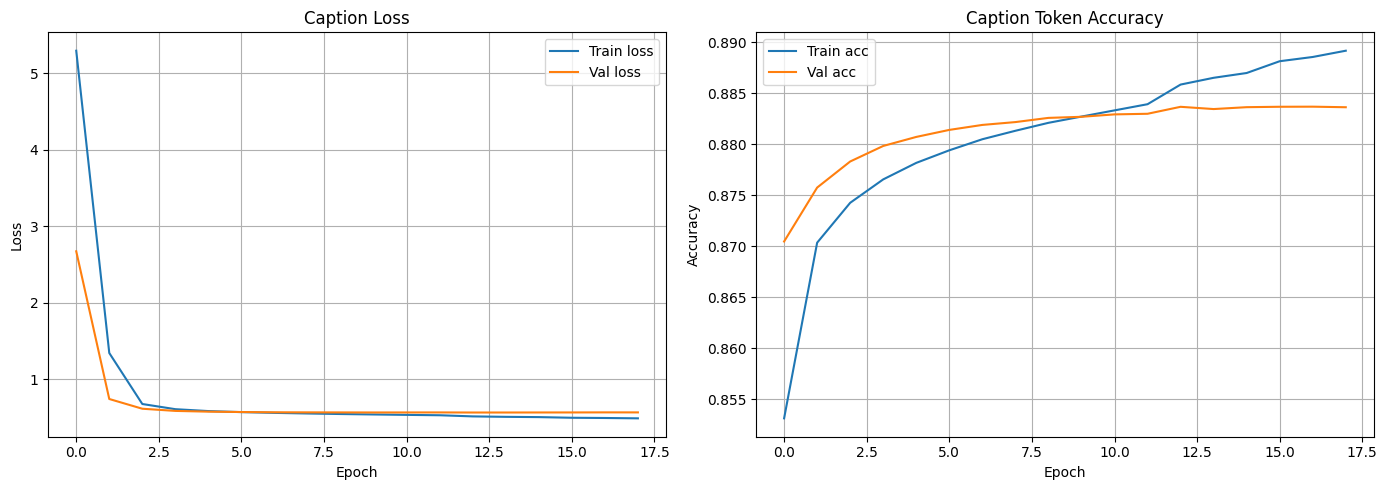

✅ Training curves saved.


In [ ]:
# ── Plot training curves ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caption loss
axes[0].plot(history.history['caption_output_loss'],     label='Train loss')
axes[0].plot(history.history['val_caption_output_loss'], label='Val loss')
axes[0].set_title('Caption Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Caption accuracy
axes[1].plot(history.history['caption_output_accuracy'],     label='Train acc')
axes[1].plot(history.history['val_caption_output_accuracy'], label='Val acc')
axes[1].set_title('Caption Token Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('✅ Training curves saved.')

## 5 · Caption Generation (Inference)

At inference time we use **greedy decoding**: at each step we pick the most likely next word until `<end>` is produced or we hit `MAX_LEN`.

In [ ]:
# ── Greedy caption generation ──────────────────────────────────────

def generate_caption(img_feature: np.ndarray, max_len: int = MAX_LEN) -> str:
    """
    Given a precomputed 1280-dim image feature vector,
    generate a caption using greedy decoding.
    """
    # Start with just the <start> token
    token_seq = [START_IDX]

    img_feat_batch = img_feature[np.newaxis, :]   # (1, 1280)

    for _ in range(max_len):
        # Pad current sequence to MAX_LEN-1
        padded = token_seq + [PAD_IDX] * (max_len - 1 - len(token_seq))
        padded = padded[:max_len - 1]
        cap_batch = np.array([padded], dtype=np.int32)

        # Forward pass
        logits, _ = captioning_model.predict(
            {'image_features': img_feat_batch, 'caption_input': cap_batch},
            verbose=0
        )
        # logits shape: (1, max_len, vocab_size)
        # Take prediction at current position (length of seq so far)
        next_idx = np.argmax(logits[0, len(token_seq) - 1, :])

        token_seq.append(int(next_idx))
        if int(next_idx) == END_IDX:
            break

    # Convert indices back to words (skip <start> and <end>)
    words = [
        idx2word.get(i, '<unk>')
        for i in token_seq
        if i not in (START_IDX, END_IDX, PAD_IDX)
    ]
    return ' '.join(words)

print('✅ Greedy decoder defined.')

✅ Greedy decoder defined.


## 6 · Evaluation (BLEU Scores)

BLEU compares the generated caption against the 5 human reference captions.  
We report **BLEU-1**, **BLEU-2**, **BLEU-3**, and **BLEU-4** on the test set (val2017).

In [ ]:
# ── BLEU evaluation ────────────────────────────────────────────────
# Use training image IDs we actually have features for (val_ids_fit)

TEST_SAMPLE = 1000

test_img_ids = [
    img_id for img_id in val_ids_fit[:TEST_SAMPLE]
    if img_id in all_features and img_id in train_captions
]

print(f'Evaluating on {len(test_img_ids)} test images...')

references = []
hypotheses = []
smooth = SmoothingFunction().method1

for img_id in test_img_ids:
    feat = all_features[img_id]
    pred = generate_caption(feat)

    hyp = pred.split()

    refs = [
        [w for w in cap.split() if w not in ('<start>', '<end>')]
        for cap in train_captions[img_id]
    ]

    hypotheses.append(hyp)
    references.append(refs)

# Compute corpus BLEU
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smooth)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

print('\n── BLEU Scores ──────────────────────────────────')
print(f'  BLEU-1 : {bleu1:.4f}')
print(f'  BLEU-2 : {bleu2:.4f}')
print(f'  BLEU-3 : {bleu3:.4f}')
print(f'  BLEU-4 : {bleu4:.4f}')
print('─────────────────────────────────────────────────')

Evaluating on 1000 test images...

── BLEU Scores ──────────────────────────────────
  BLEU-1 : 0.6727
  BLEU-2 : 0.4896
  BLEU-3 : 0.3484
  BLEU-4 : 0.2416
─────────────────────────────────────────────────


## 7 · Qualitative Results — Generated Captions on Sample Images

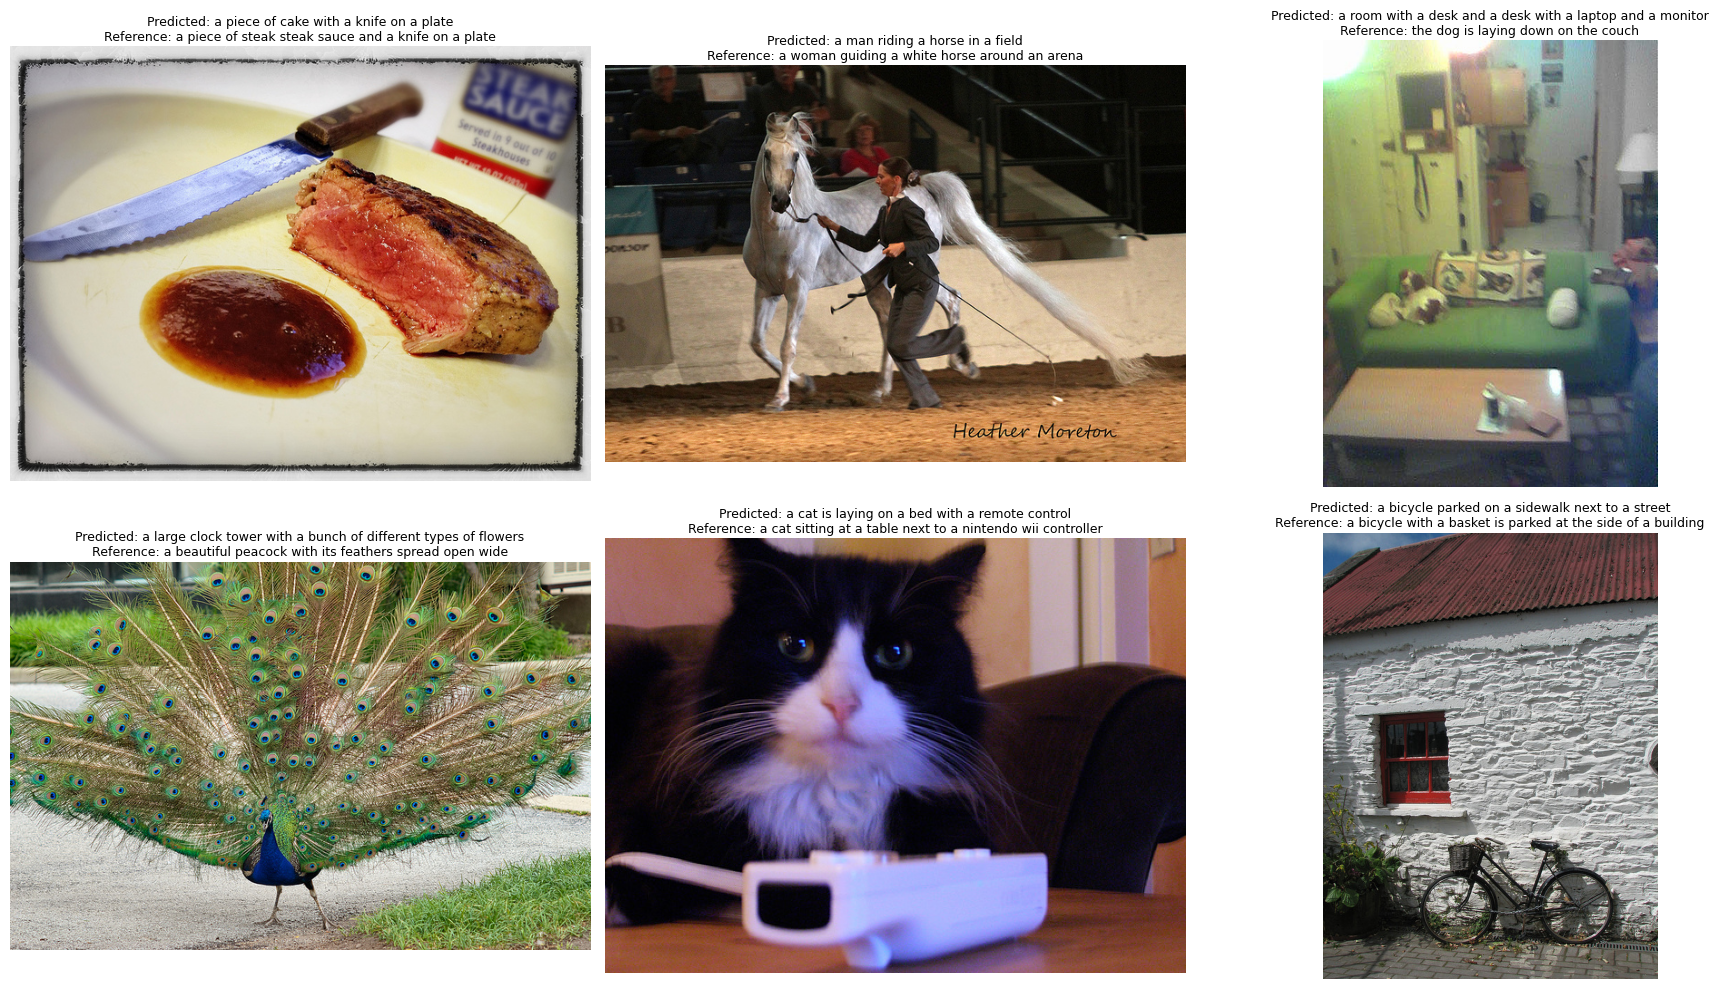

✅ Sample caption figure saved.


In [ ]:
# ── Show generated captions on sample images ───────────────────────

NUM_SAMPLES = 6

sample_ids = random.sample(test_img_ids, NUM_SAMPLES)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):
    # Use train_id2file and TRAIN_IMG_DIR since test_img_ids are training images
    img_path = TRAIN_IMG_DIR / train_id2file[img_id]
    img      = Image.open(img_path).convert('RGB')

    pred_caption = generate_caption(all_features[img_id])
    ref_caption  = train_captions[img_id][0]
    ref_caption  = ref_caption.replace('<start>', '').replace('<end>', '').strip()

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'Predicted: {pred_caption}\nReference: {ref_caption}',
        fontsize=9, wrap=True
    )

plt.tight_layout()
plt.savefig('sample_captions.png', dpi=150)
plt.show()
print('✅ Sample caption figure saved.')

## 8 · Save & Load Model

In [ ]:
# ── Save the final model and vocabulary ────────────────────────────

captioning_model.save('image_captioning_final.keras')

vocab_data = {
    'word2idx'   : word2idx,
    'idx2word'   : idx2word,
    'vocab_size' : VOCAB_SIZE,
    'max_len'    : MAX_LEN,
    'special'    : {'pad': PAD_IDX, 'unk': UNK_IDX,
                    'start': START_IDX, 'end': END_IDX}
}
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)

print('✅ Model and vocabulary saved.')

✅ Model and vocabulary saved.


In [ ]:
# ── Load model (use this cell to resume without re-training) ───────

# loaded_model = keras.models.load_model('image_captioning_final.keras')
# with open('vocab.pkl', 'rb') as f:
#     vocab_data = pickle.load(f)
# word2idx  = vocab_data['word2idx']
# idx2word  = vocab_data['idx2word']
# MAX_LEN   = vocab_data['max_len']
# START_IDX = vocab_data['special']['start']
# END_IDX   = vocab_data['special']['end']
# PAD_IDX   = vocab_data['special']['pad']
print('(Uncomment the lines above to load a saved model.)')

(Uncomment the lines above to load a saved model.)


## 9 · Caption Your Own Image

In [ ]:
# ── Caption any image from your local files ────────────────────────
# Change MY_IMAGE_PATH to point to any .jpg / .png image.

MY_IMAGE_PATH = 'your_image.jpg'   # <── change this

if Path(MY_IMAGE_PATH).exists():
    img   = Image.open(MY_IMAGE_PATH).convert('RGB')
    arr   = np.array(img.resize(IMAGE_SIZE), dtype=np.float32)
    arr   = preprocess_input(arr)[np.newaxis, :]     # (1, 224, 224, 3)
    feat  = cnn_extractor.predict(arr, verbose=0)[0] # (1280,)
    caption = generate_caption(feat)

    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Generated caption:\n"{caption}"', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f'Caption: {caption}')
else:
    print(f'File not found: {MY_IMAGE_PATH}  — update the path above.')

File not found: your_image.jpg  — update the path above.
